In [1]:
import sys
sys.path.append('/code')

import os

os.environ['OMP_NUM_THREADS'] = '1'
import argparse
import sys
import shutil
from distutils.dir_util import copy_tree
import datetime
import tqdm
import numpy as np
import torch
import torch.optim as optim
import torchvision.transforms as T
from multiview_detector.datasets import *
from multiview_detector.loss.gaussian_mse import GaussianMSE, WeightedGaussianMSE
from multiview_detector.models.persp_trans_detector import PerspTransDetector
from multiview_detector.models.image_proj_variant import ImageProjVariant
from multiview_detector.models.res_proj_variant import ResProjVariant
from multiview_detector.models.no_joint_conv_variant import NoJointConvVariant
from multiview_detector.utils.logger import Logger
from multiview_detector.utils.draw_curve import draw_curve2
from multiview_detector.utils.image_utils import img_color_denormalize
from multiview_detector.trainer import PerspectiveTrainer, UDATrainer, Augmentation
from multiview_detector.datasets.concat_dataset import ConcatDataset
from multiview_detector.datasets.dataloader import GetDataset
import csv

def main(args):
    # seed
    if args.seed is not None:
        np.random.seed(args.seed)
        torch.manual_seed(args.seed)
        # torch.backends.cudnn.deterministic = True
        # torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.benchmark = True
    else:
        torch.backends.cudnn.benchmark = True

    # dataset
    normalize = T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    denormalize = img_color_denormalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    train_trans = T.Compose([T.Resize([720, 1280]), T.ToTensor(), normalize, ])


    if args.gmvd2multiviewx:
        # set multiview x as target dataset and test dataset
        data_path = args.data_path_src
        # test_base0 = MultiviewX(data_path, False, [x for x in np.arange(6)], [x for x in np.arange(6)])
        print("\nTraining datasets trg")
        target_base = MultiviewX(data_path)
        train_dataset_trg_ = frameDataset(target_base, train=True, transform=train_trans, grid_reduce=4, img_reduce=4)
        train_dataset_trg = ConcatDataset(train_dataset_trg_)

        print("\nTest datasets trg")
        test_base0 = MultiviewX(data_path)
        test_set = frameDataset(test_base0, train=False, transform=train_trans, grid_reduce=4, img_reduce=4)
        test_dataset_ = ConcatDataset(test_set)

        # print("\nTraining datasets src")
        # source_base0 = MultiviewX(data_path)
        # train_set = frameDataset(source_base0, train=True, transform=train_trans, grid_reduce=4, img_reduce=4)
        # train_set_ = ConcatDataset(train_set)

        # set gmvd train as source dataset
        print("\nTraining datasets source")
        data_root = args.data_path_trg
        train_dataset_list = []
        print(os.path.join(data_root,args.gmvd_csv))
        f = open(os.path.join(data_root,args.gmvd_csv))
            #data_path = f.readlines()
        data_path = csv.reader(f)
        #for i in range(len(data_path)):
        for i,data_row in enumerate(data_path):
            #print(data_row[1])
            train_ratio = float(data_row[2])
            sample_require = int(data_row[3])
            # path = os.path.expanduser(str(data_row[1]))
            path = os.path.join(data_root, str(data_row[1]))
            if data_row[1].split('/')[-1]!='Wildtrack':
                base = MultiviewX(path)
            else:
                base = Wildtrack(path)
            if data_row[0]=='train':
                # Train data
                dataset_obj = GetDataset(base, train=True, transform=train_trans, grid_reduce=4, img_reduce=4, train_ratio=train_ratio, sample_require=sample_require)
                train_dataset_list.append(dataset_obj)
        train_set_ = ConcatDataset(*train_dataset_list)

        # # set gmvd train as source dataset
        # print("\nTraining datasets source")
        # data_root = args.data_path
        # train_dataset_list = []
        # print(os.path.join(data_root,'train_datapath.csv'))
        # f = open(os.path.join(data_root,'train_datapath.csv'))
        #     #data_path = f.readlines()
        # data_path = csv.reader(f)
        # #for i in range(len(data_path)):
        # for i,data_row in enumerate(data_path):
        #     #print(data_row[1])
        #     train_ratio = float(data_row[2])
        #     sample_require = int(data_row[3])
        #     # path = os.path.expanduser(str(data_row[1]))
        #     path = os.path.join(data_root, str(data_row[1]))
        #     if data_row[1].split('/')[-1]!='Wildtrack':
        #         base = MultiviewX(path)
        #     else:
        #         base = Wildtrack(path)
        #     if data_row[0]=='train':
        #         # Train data
        #         dataset_obj = frameDataset(base, train=True, transform=train_trans, grid_reduce=4, img_reduce=4, train_ratio=train_ratio)
        #         train_dataset_list.append(dataset_obj)
        # train_dataset = ConcatDataset(*train_dataset_list)

        train_loader = torch.utils.data.DataLoader(train_set_, batch_size=args.batch_size, shuffle=True,
                                                num_workers=args.num_workers, pin_memory=True)
        train_loader_target = torch.utils.data.DataLoader(train_dataset_trg, batch_size=args.batch_size, shuffle=True,
                                                num_workers=args.num_workers, pin_memory=True)
        test_loader = torch.utils.data.DataLoader(test_dataset_, batch_size=args.batch_size, shuffle=False,
                                                num_workers=args.num_workers, pin_memory=True)
        
        print("images in source training set: ", len(train_loader))
        print("images in target training set: ", len(train_loader_target))
        print("images in target test set: ", len(test_loader))

    else:

        if 'wildtrack' in args.dataset:
            # data_path = os.path.expanduser('/data/Wildtrack')
            data_path = args.data_path
            if args.cam_adapt:
                assert args.src_cams is not None and args.trg_cams is not None, "src_cams and trg_cams must be specified in cam_adapt setting"
                trg_cams = args.trg_cams.split(",")
                trg_cams = [int(x) for x in trg_cams]

                src_cams = args.src_cams.split(",")
                src_cams = [int(x) for x in src_cams]

                source_base = Wildtrack(data_path, cameras=src_cams)
                target_base = Wildtrack(data_path, cameras=trg_cams)
                test_base = Wildtrack(data_path, cameras=trg_cams)

                train_set = frameDataset(source_base, train=True, transform=train_trans, grid_reduce=4)
                train_set_target = frameDataset(target_base, train=True, transform=train_trans, grid_reduce=4)
                test_set = frameDataset(test_base, train=False, transform=train_trans, grid_reduce=4)

                train_loader = torch.utils.data.DataLoader(train_set, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                train_loader_target = torch.utils.data.DataLoader(train_set_target, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                test_loader = torch.utils.data.DataLoader(test_set, batch_size=args.batch_size, shuffle=False,
                                                        num_workers=args.num_workers, pin_memory=True)
            else:
                base = Wildtrack(data_path)
                test_base = base

                train_set = frameDataset(base, train=True, transform=train_trans, grid_reduce=4)
                test_set = frameDataset(test_base, train=False, transform=train_trans, grid_reduce=4)

                train_loader = torch.utils.data.DataLoader(train_set, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                
                test_loader = torch.utils.data.DataLoader(test_set, batch_size=args.batch_size, shuffle=False,
                                                        num_workers=args.num_workers, pin_memory=True)

        elif 'multiviewx' in args.dataset:
            data_path = args.data_path
            if args.cam_adapt:
                assert args.src_cams is not None and args.trg_cams is not None, "src_cams and trg_cams must be specified in cam_adapt setting"
                trg_cams = args.trg_cams.split(",")
                trg_cams = [int(x) for x in trg_cams]

                src_cams = args.src_cams.split(",")
                src_cams = [int(x) for x in src_cams]

                source_base = MultiviewX(data_path, cameras=src_cams)
                target_base = MultiviewX(data_path, cameras=trg_cams)
                test_base = MultiviewX(data_path, cameras=trg_cams)

                train_set = frameDataset(source_base, train=True, transform=train_trans, grid_reduce=4)
                train_set_target = frameDataset(target_base, train=True, transform=train_trans, grid_reduce=4)
                test_set = frameDataset(test_base, train=False, transform=train_trans, grid_reduce=4)

                train_loader = torch.utils.data.DataLoader(train_set, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                train_loader_target = torch.utils.data.DataLoader(train_set_target, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                test_loader = torch.utils.data.DataLoader(test_set, batch_size=args.batch_size, shuffle=False,
                                                        num_workers=args.num_workers, pin_memory=True)
            else:
                base = MultiviewX(data_path)
                test_base = base

                train_set = frameDataset(base, train=True, transform=train_trans, grid_reduce=4)
                train_dataset = ConcatDataset(train_set)
                test_set = frameDataset(test_base, train=False, transform=train_trans, grid_reduce=4)
                test_dataset = ConcatDataset(test_set)

                train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                
                test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False,
                                                        num_workers=args.num_workers, pin_memory=True)

        else:
            raise Exception('must choose from [wildtrack, multiviewx]')



    # model
    if args.variant == 'default':
        model = PerspTransDetector(args.arch, pretrained=args.pretrained, avgpool=args.avgpool, avgpool_ext=args.avgpool_ext)

        if args.uda:
            # init ema model
            ema_model = PerspTransDetector(args.arch, pretrained=args.pretrained, avgpool=args.avgpool, avgpool_ext=args.avgpool_ext)
            for param in ema_model.parameters():
                param.detach_()
            mp = list(model.parameters())
            mcp = list(ema_model.parameters())
            n = len(mp)
            for i in range(0, n):
                mcp[i].data[:] = mp[i].data[:].clone()

    elif args.variant == 'img_proj':
        model = ImageProjVariant(train_set, args.arch)
    elif args.variant == 'res_proj':
        model = ResProjVariant(train_set, args.arch)
    elif args.variant == 'no_joint_conv':
        model = NoJointConvVariant(train_set, args.arch)
    else:
        raise Exception('no support for this variant')

    optimizer = optim.SGD(model.parameters(), lr=args.lr, momentum=args.momentum, weight_decay=args.weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=args.lr, steps_per_epoch=len(train_loader),
                                                    epochs=args.epochs)

    # loss
    criterion = WeightedGaussianMSE().cuda()


    # logging
    logdir = f'logs/{args.dataset}_frame/{args.variant}/' + datetime.datetime.today().strftime('%Y-%m-%d_%H-%M-%S-%f')# if not args.resume else f'logs/{args.dataset}_frame/{args.variant}/{args.resume}'
    if args.log_dir is not None:
        logdir = os.path.join(args.log_dir, logdir)

    # if args.resume is None:
    os.makedirs(logdir, exist_ok=True)

    # copying files like this gave rise to issues on the cluster when running many experiments simultaneously
    # copy_tree('./multiview_detector', logdir + '/scripts/multiview_detector')
    # for script in os.listdir('.'):
    #     if script.split('.')[-1] == 'py':
    #         dst_file = os.path.join(logdir, 'scripts', os.path.basename(script))
    #         shutil.copyfile(script, dst_file)
    sys.stdout = Logger(os.path.join(logdir, 'log.txt'), )
    print('Settings:')
    for k, v in vars(args).items():
        print(k, ": ", v)

    print("logdir: ", logdir)

    # draw curve
    x_epoch = []
    train_loss_s = []
    # train_prec_s = []
    test_loss_s = []
    test_prec_s = []
    test_moda_s = []
    test_modp_s = []
    test_recall_s = []

    test_prec_s_04 = []
    test_moda_s_04 = []
    test_modp_s_04 = []
    test_recall_s_04 = []
    cls_thres_list_var= []
    cls_thres_list_fix = []

    augmentation = Augmentation(args.dropview, args.permutation, args.mvaug)

    if args.uda:
        pom = train_dataset_list[0].base.read_pom() # TODO doesn't generalize to multiple target datasets
        trainer = UDATrainer(model, ema_model, criterion, logdir, denormalize, args.cls_thres, args.alpha, pom,
                             args.train_viz, target_cameras=target_base.cameras,
                             alpha_teacher=args.alpha_teacher, soft_labels=args.soft_labels,
                             augmentation_module=augmentation, weighted_mse=args.weighted_mse,
                             low_th=args.low_th, high_th=args.high_th, uda_persp_sup=args.uda_persp_sup, persp_sup=args.persp_sup)
    else:
        trainer = PerspectiveTrainer(model, criterion, logdir, denormalize, args.cls_thres, args.alpha, augmentation_module=augmentation, persp_sup=args.persp_sup)

    # learn
    if args.resume_model is not None:
        # resume_dir = f'logs/{args.dataset}_frame/{args.variant}/' + args.resume
        # resume_fname = resume_dir + '/MultiviewDetector.pth'
        resume_fname = args.resume_model
        print("Loading saved model from: ", resume_fname)
        model.load_state_dict(torch.load(resume_fname))


    if args.uda:
        if args.target_epoch_start is None or args.target_weight_start is None or args.target_weight_end is None:
            # randomize the target weight schedule
            # target_epoch_start = np.random.choice(10) + 1
            target_epoch_start = np.random.choice(7) + 5
            target_weight_start = np.random.rand() + 0.5
            target_weight_end = target_weight_start + (1- target_weight_start)*np.random.rand()
        else:
            target_epoch_start = args.target_epoch_start
            target_weight_start = args.target_weight_start
            target_weight_end = args.target_weight_end
        
        target_weights = [0. for x in range(args.epochs)]
        increment_steps = args.epochs - target_epoch_start
        if increment_steps == 0:
            step_size = 0
        else:
            step_size = (target_weight_end - target_weight_start) / increment_steps
        for i in range(increment_steps + 1):
            target_weights[i + target_epoch_start - 1] = target_weight_start + step_size * i

        print("target_epoch_start: ", target_epoch_start)
        print("target_weight_start: ", target_weight_start)
        print("target_weight_end: ", target_weight_end)
        print("target_weights: ", target_weights)

        if args.pseudo_label_th is None:
            pseudo_label_th = 0.37 + np.random.rand()*0.05 # random value between 0.3 and 0.45
        else:
            pseudo_label_th = args.pseudo_label_th
        print("pseudo_label_th: ", pseudo_label_th)

    print('Testing...')
    # test_loss, test_prec, moda, modp, precision, recall  = trainer.test(test_loader, os.path.join(logdir, 'test.txt'),
    #                                             test_set.gt_fpath)

    return test_loader, model, criterion

In [2]:
parser = argparse.ArgumentParser(description='Multiview detector')
parser.add_argument('--reID', action='store_true')
parser.add_argument('--cls_thres', type=float, default=0.4)
parser.add_argument('--alpha', type=float, default=1.0, help='ratio for per view loss')
parser.add_argument('--variant', type=str, default='default',
                    choices=['default', 'img_proj', 'res_proj', 'no_joint_conv'])
parser.add_argument('--arch', type=str, default='resnet18', choices=['vgg11', 'resnet18'])
parser.add_argument('-d', '--dataset', type=str, default='wildtrack', choices=['wildtrack', 'multiviewx'])
parser.add_argument("--data_path", type=str, default=None)
parser.add_argument("--data_path_src", type=str, default=None)
parser.add_argument("--data_path_trg", type=str, default=None)
parser.add_argument("--gmvd_csv", type=str, default="train_datapath.csv")
parser.add_argument('-j', '--num_workers', type=int, default=4)
parser.add_argument('-b', '--batch_size', type=int, default=1, metavar='N',
                    help='input batch size for training (default: 1)')
parser.add_argument('--epochs', type=int, default=10, metavar='N', help='number of epochs to train (default: 10)')
parser.add_argument('--lr', type=float, default=0.1, metavar='LR', help='learning rate (default: 0.1)')
parser.add_argument('--weight_decay', type=float, default=5e-4)
parser.add_argument('--momentum', type=float, default=0.5, metavar='M', help='SGD momentum (default: 0.5)')
parser.add_argument('--log_interval', type=int, default=40, metavar='N',
                    help='how many batches to wait before logging training status')
parser.add_argument('--resume_model', type=str, default=None)
parser.add_argument('--log_dir', type=str, default=None)
parser.add_argument('--config', type=str, default=None)
parser.add_argument('--visualize', action='store_true')
parser.add_argument('--train_viz', action='store_true')
parser.add_argument('--seed', type=int, default=1, help='random seed (default: None)')
parser.add_argument('--cam_adapt', action="store_true")
parser.add_argument('--uda', action="store_true")
parser.add_argument('--dropview', action="store_true")
parser.add_argument("--permutation", action="store_true")
parser.add_argument("--mvaug", action="store_true")
parser.add_argument('--soft_labels', action="store_true")
parser.add_argument('--pretrained', action="store_true")
parser.add_argument('--src_cams', type=str, default=None)
parser.add_argument('--trg_cams', type=str, default=None)
parser.add_argument('--alpha_teacher', type=float, default=0.99)
parser.add_argument('--avgpool', action="store_true")
parser.add_argument('--avgpool_ext', action="store_true")
parser.add_argument('--weighted_mse', action="store_true")
parser.add_argument('--uda_persp_sup', action="store_true")
parser.add_argument('--varying_cls_thres', action="store_true")
parser.add_argument('--gmvd2multiviewx', action="store_true")
parser.add_argument('--persp_sup', action="store_true", default=True)
parser.add_argument('--low_th', type=float, default=0.1, help='The threshold used for mining confident negatives in UDA setting')
parser.add_argument('--high_th', type=float, default=0.9, help='The threhsold used for mining confident positive in UDA setting')

# below parameters are randomized if not set
parser.add_argument('--target_epoch_start', type=int, default=None, help='the epoch at which training on target domain starts')
parser.add_argument('--target_weight_start', type=float, default=None, help='the initial weight when training on target domain starts')
parser.add_argument('--target_weight_end', type=float, default=None, help='the final weight when training on target domain ends')
parser.add_argument('--pseudo_label_th', type=float, default=None, help='confidenbce threshold for creating pseudo-labels')


args = parser.parse_args(args=[])

In [3]:

args.dataset = "multiviewx"
args.train_viz = True
args.data_path = "/data/MultiviewX"
args.avgpool = True
args.resume_model = "/mnt/2024-09-13_08-54-23-114946/MultiviewDetector.pth"

In [4]:
test_loader, model, criterion = main(args)

/data/MultiviewX
Dataset Name : MultiviewX
Cameras : 6, Frames : 400
Image Shape(H,W) : [1080, 1920]
Grid Shape(rows,cols) : [640, 1000]
Grid Cell(in cm) : 0.025cm i.e 0.00025m
Grid Origin(x,y) : [0, 0]
Area/Region size(in m) : 16m x 25m
['/data/MultiviewX']
['/data/MultiviewX']
Settings:
reID :  False
cls_thres :  0.4
alpha :  1.0
variant :  default
arch :  resnet18
dataset :  multiviewx
data_path :  /data/MultiviewX
data_path_src :  None
data_path_trg :  None
gmvd_csv :  train_datapath.csv
num_workers :  4
batch_size :  1
epochs :  10
lr :  0.1
weight_decay :  0.0005
momentum :  0.5
log_interval :  40
resume_model :  /mnt/2024-09-13_08-54-23-114946/MultiviewDetector.pth
log_dir :  None
config :  None
visualize :  False
train_viz :  True
seed :  1
cam_adapt :  False
uda :  False
dropview :  False
permutation :  False
mvaug :  False
soft_labels :  False
pretrained :  False
src_cams :  None
trg_cams :  None
alpha_teacher :  0.99
avgpool :  True
avgpool_ext :  False
weighted_mse :  False

In [5]:
iterator = iter(test_loader)

In [6]:
(data, map_gt, imgs_gt, frame, proj_mats, _, _, _, _, dataset_name) = next(iterator)
with torch.no_grad():
    config_dict = test_loader.dataset.dicts[dataset_name[0]]

    map_res, imgs_res = model(data, proj_mats, config_dict)

    temp = map_res.detach().cpu().squeeze()

In [7]:
from multiview_detector.evaluation.pyeval.CLEAR_MOD_HUN import CLEAR_MOD_HUN
from multiview_detector.utils.nms import nms

def eval_det(positions, scores, gt_pos):
    gtAllMatrix = np.zeros((gt_pos.shape[0], 4))
    gtAllMatrix[:,1] = np.array([i for i in range(gtAllMatrix.shape[0])])
    gtAllMatrix[:,2] = gt_pos[:,0].cpu().detach().numpy() * test_loader.dataset.dicts[dataset_name[0]]['base'].grid_reduce
    gtAllMatrix[:,3] = gt_pos[:,1].cpu().detach().numpy() * test_loader.dataset.dicts[dataset_name[0]]['base'].grid_reduce

    if not torch.numel(positions) == 0:
        ids, count = nms(positions.float(), scores, 20 / test_loader.dataset.dicts[dataset_name[0]]['base'].grid_reduce, np.inf)
        # ids, count = nms(positions.float(), scores, 20 , np.inf)
        positions = positions[ids[:count], :]
        scores = scores[ids[:count]]

        detAllMatrix = np.zeros((positions.shape[0], 4))
        detAllMatrix[:,1] = np.array([i for i in range(detAllMatrix.shape[0])])
        detAllMatrix[:,2] = positions[:,0].cpu().detach().numpy() * test_loader.dataset.dicts[dataset_name[0]]['base'].grid_reduce
        detAllMatrix[:,3] = positions[:,1].cpu().detach().numpy() * test_loader.dataset.dicts[dataset_name[0]]['base'].grid_reduce
        _, _, moda_i, _ = CLEAR_MOD_HUN(gtAllMatrix, detAllMatrix) # CLEAR MOD HUN uses distance threshold 20, so it expects gt and pred at full scale

        return moda_i
    else:
        return 0

gt_pos = (map_gt.detach().cpu().squeeze() > 0).nonzero().float()

# find the optimal (in moda sense) pseudo-label threshold for the current sample
best_th = 0.4 # use 0.4 if moda is 0 for all varying_th
best_moda = 0
moda_04 = 0
for varying_th in np.arange(0.05, 0.95, 0.05):
    scores = temp[temp > varying_th]
    positions = (temp > varying_th).nonzero().float()
    moda_i = eval_det(positions, scores, gt_pos)
    if moda_i > best_moda:
        best_moda = moda_i
        best_th = varying_th
    if varying_th == 0.4:
        moda_04 = moda_i
pseudo_label_th = best_th

# pseudo_label_th = 0.1
scores = temp[temp > pseudo_label_th]
positions = (temp > pseudo_label_th).nonzero().float()

moda = eval_det(positions, scores, gt_pos)
print("test_moda:", moda)

# if data_loader.dataset.base.indexing == 'xy':
#     positions = positions[:, [1, 0]]
# else:
#     positions = positions
if not torch.numel(positions) == 0:
    # ids, count = nms(positions.float(), scores, 20 / test_loader.dataset.dicts[dataset_name[0]]['base'].grid_reduce, np.inf)
    ids, count = nms(positions.float(), scores, 5, np.inf)
    positions = positions[ids[:count], :]
    scores = scores[ids[:count]]
map_pseudo_label = torch.zeros_like(map_res)
for pos in positions:
    map_pseudo_label[:,:,int(pos[0].item()), int(pos[1].item())] = 1
                    

test_moda: 60.526315789473685


In [8]:
pseudo_label_th

0.25

In [9]:
moda

60.526315789473685

/tmp/ipykernel_69715/1314629873.py:16: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  cam_i = test_loader.dataset.dicts[dataset_name[0]]["base"].base.display_cam_layout([i])


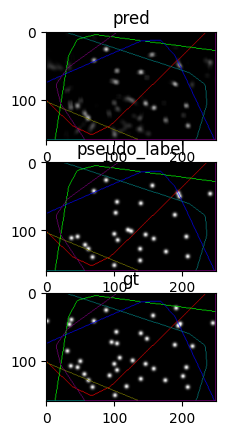

In [10]:
from PIL import Image
import cv2

def draw_cam_layout(drawing):
    drawing = np.copy(drawing)
    color_list = [
        (255,0,0),
        (0,255,0),
        (0,0,255),
        (127,127,0),
        (0,127,127),
        (127,0,127)
    ]
    all_contours = []
    for i in range(6):
        cam_i = test_loader.dataset.dicts[dataset_name[0]]["base"].base.display_cam_layout([i])
        # cam_i[0:5,:] = 0
        # cam_i[:,0:5] = 0
        # cam_i[-5:,:] = 0
        # cam_i[:,-5:] = 0
        cam_i[0:1,:] = 0
        cam_i[:,0:1] = 0
        cam_i[-1:,:] = 0
        cam_i[:,-1:] = 0

        blur = cv2.blur(cam_i.astype(np.uint8)*255, (3, 3)) # blur the image
        blur = cv2.resize(blur, (drawing.shape[1], drawing.shape[0]))
        ret, thresh = cv2.threshold(blur, 50, 255, cv2.THRESH_BINARY)

        contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        # create hull array for convex hull points
        hull = []

        # calculate points for each contour
        for j in range(len(contours)):
            # creating convex hull object for each contour
            hull.append(cv2.convexHull(contours[j], False))
            
        # draw contours and hull points
        # for j in range(len(contours)):
        #     color_contours = (0, 255, 0) # green - color for contours
        color = (255, 0, 0) 
        drawing=cv2.drawContours(drawing, hull, -1, color_list[i], 1)

    return drawing
            


%matplotlib nbagg
import matplotlib.pyplot as plt
%matplotlib inline

temp = 255*map_res.cpu().detach().numpy().squeeze()
temp = np.maximum(temp, 0)
temp = np.minimum(255, temp)
temp = temp.astype(np.uint8)
drawing = draw_cam_layout(np.repeat(np.expand_dims(temp, axis=2), 3, axis=2))

temp = 255*criterion._traget_transform(map_res, map_gt, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
temp = np.maximum(temp, 0)
temp = np.minimum(255, temp)
temp = temp.astype(np.uint8)
drawing2 = draw_cam_layout(np.repeat(np.expand_dims(temp, axis=2), 3, axis=2))

temp = 255*criterion._traget_transform(map_res, map_pseudo_label, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
temp = np.maximum(temp, 0)
temp = np.minimum(255, temp)
temp = temp.astype(np.uint8)
drawing3 = draw_cam_layout(np.repeat(np.expand_dims(temp, axis=2), 3, axis=2))

fig = plt.figure()
subplt0 = fig.add_subplot(311, title="pred")
subplt1 = fig.add_subplot(312, title="pseudo_label")
subplt2 = fig.add_subplot(313, title="gt")
subplt0.imshow(drawing)
subplt2.imshow(drawing2)
subplt1.imshow(drawing3)
# plt.show()